In [ ]:
import os, copy, json, time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from google.colab import drive

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive.mount('/content/drive')
CHECKPOINT_DIR = "/content/drive/MyDrive/AML_Dataset/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CONFIG_NAME = "nfnet_frozenFalse_lossce"
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/{CONFIG_NAME}_checkpoint.pth"

!pip install timm grad-cam -q
import timm

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from google.colab import files
uploaded = files.upload()

import zipfile
with zipfile.ZipFile("WaRP-C-preprocessed.zip", "r") as z:
    z.extractall("/content/WaRP-C-preprocessed")

Saving WaRP-C-preprocessed.zip to WaRP-C-preprocessed.zip


In [ ]:
PREPROCESSED_ROOT = "/content/WaRP-C-preprocessed"
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CFG = {
    "num_classes":28,
    "model_name": "dm_nfnet_f0",   # NFNet-F0, ~71M params, supervised ImageNet-pretrained
    "freeze_backbone": False,
    "loss_type": "ce",            # plain CrossEntropy , no imbalance handling
    "lr":3e-4,
    "min_lr": 1e-6,
    "weight_decay":0.05,
    "label_smoothing": 0.1,
    "focal_gamma":2.0,
    "warmup_epochs":3,
    "num_epochs":15,
    "blend_alpha":0.4,
    "early_stop_patience":5,
}

full_train_pipeline = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

eval_pipeline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
def _make_flat_dataset(root_dir, transform):
    samples, class_to_idx = [], {}
    for superclass in sorted(os.listdir(root_dir)):
        sp = os.path.join(root_dir, superclass)
        if not os.path.isdir(sp): continue
        for subclass in sorted(os.listdir(sp)):
            scp = os.path.join(sp, subclass)
            if not os.path.isdir(scp): continue
            if subclass not in class_to_idx:
                class_to_idx[subclass] = len(class_to_idx)
            for img_name in os.listdir(scp):
                if img_name.lower().endswith(".jpg"):
                    samples.append((os.path.join(scp, img_name), class_to_idx[subclass]))
    dataset = datasets.ImageFolder(root_dir, transform=transform)
    dataset.samples = dataset.imgs = samples
    dataset.targets = [s[1] for s in samples]
    dataset.classes = list(class_to_idx.keys())
    dataset.class_to_idx = class_to_idx
    return dataset


def get_dataloaders(root=PREPROCESSED_ROOT, batch_size=32, num_workers=2, seed=42):
    torch.manual_seed(seed)
    train_ds = _make_flat_dataset(f"{root}/train", transform=full_train_pipeline)
    val_ds   = _make_flat_dataset(f"{root}/val",   transform=eval_pipeline)
    test_ds  = _make_flat_dataset(f"{root}/test",  transform=eval_pipeline)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader= DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                               num_workers=num_workers, pin_memory=True)
    test_loader= DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                               num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader, train_ds, val_ds, test_ds


def get_class_counts(dataset):
    counts = np.bincount(dataset.targets, minlength=len(dataset.classes))
    return counts.astype(np.float32)


train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = get_dataloaders()
num_classes = len(train_loader.dataset.classes)
print(f"Classes: {num_classes} | Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Classes: 28 | Train: 7058 | Val: 1765 | Test: 1551


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(
            logits, targets, weight=self.weight,
            label_smoothing=self.label_smoothing, reduction="none"
        )
        pt = torch.exp(-ce_loss)
        focal_term = (1 - pt) ** self.gamma
        return (focal_term * ce_loss).mean()


def get_criterion(loss_type, samples_per_class=None, device=None, label_smoothing=0.1, gamma=2.0):
    weight = None
    if loss_type in ("weighted_ce", "focal") and samples_per_class is not None:
        freq_inverse = 1.0 / (samples_per_class + 1e-6)
        weight = torch.tensor(freq_inverse / freq_inverse.sum(), dtype=torch.float).to(device)

    if loss_type == "ce":
        return nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    elif loss_type == "weighted_ce":
        return nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing)
    elif loss_type == "focal":
        return FocalLoss(weight=weight, gamma=gamma, label_smoothing=label_smoothing)
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")

In [ ]:
#Build the model
def build_nfnet(num_classes, freeze_backbone=False):
    model = timm.create_model(CFG["model_name"], pretrained=True, num_classes=num_classes)
    if freeze_backbone:
        for name, param in model.named_parameters():
            if "head" not in name and "fc" not in name and "classifier" not in name:
                param.requires_grad = False
    return model


def get_param_groups(model):
    head_params, backbone_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "head" in name or "fc" in name or "classifier" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
    return backbone_params, head_params


model = build_nfnet(num_classes, freeze_backbone=CFG["freeze_backbone"]).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable: {trainable:,}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  286MB            

model.safetensors: downloading bytes:           |  0.00B            

Total params: 68,502,328 | Trainable: 68,502,328


In [ ]:
samples_per_class = get_class_counts(train_ds)
criterion = get_criterion(CFG["loss_type"], samples_per_class=samples_per_class, device=device,
                           label_smoothing=CFG["label_smoothing"], gamma=CFG["focal_gamma"])

backbone_params, head_params = get_param_groups(model)
if CFG["freeze_backbone"]:
    optimizer = optim.AdamW(head_params, lr=CFG["lr"], weight_decay=CFG["weight_decay"])
else:
    optimizer = optim.AdamW([
        {"params": backbone_params, "lr": CFG["lr"] / 10},
        {"params": head_params, "lr": CFG["lr"]},
    ], weight_decay=CFG["weight_decay"])

def get_lr_scale(epoch):
    if epoch < CFG["warmup_epochs"]:
        return (epoch + 1) / CFG["warmup_epochs"]
    decay_progress = (epoch - CFG["warmup_epochs"]) / max(1, CFG["num_epochs"] - CFG["warmup_epochs"])
    return CFG["min_lr"] / CFG["lr"] + 0.5 * (1 - CFG["min_lr"] / CFG["lr"]) * (1 + np.cos(np.pi * decay_progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, get_lr_scale)

In [ ]:
def mixup_data(x, y, alpha=1.0):
    blend_ratio = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).to(x.device)
    blended_imgs = blend_ratio * x + (1 - blend_ratio) * x[index, :]
    return blended_imgs, y, y[index], blend_ratio

def mixup_criterion(criterion, pred, labels_orig, labels_mixed, blend_ratio):
    return blend_ratio * criterion(pred, labels_orig) + (1 - blend_ratio) * criterion(pred, labels_mixed)

def train_one_epoch(model, loader, optimizer, criterion, blend_alpha=0.0):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        if blend_alpha > 0:
            imgs, labels_orig, labels_mixed, blend_ratio = mixup_data(imgs, labels, blend_alpha)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = mixup_criterion(criterion, logits, labels_orig, labels_mixed, blend_ratio) if blend_alpha > 0 else criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, eval_device=None):
    eval_device = eval_device or device
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(eval_device), labels.to(eval_device)
        logits = model(imgs)
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels

In [ ]:
#Run the model
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc, patience_counter, start_epoch = 0.0, 0, 0

if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_acc = ckpt["best_val_acc"]
    patience_counter = ckpt["patience_counter"]
    history = ckpt["history"]

best_state = copy.deepcopy(model.state_dict())

for epoch in range(start_epoch, CFG["num_epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, blend_alpha=CFG["blend_alpha"])
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    epoch_lr = optimizer.param_groups[0]["lr"]
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1:02d}/{CFG['num_epochs']}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} | LR: {epoch_lr:.2e}")

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  New best val acc: {best_val_acc:.4f}")
    else:
        patience_counter += 1

    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "best_model_state": best_state,
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_acc": best_val_acc,
        "patience_counter": patience_counter,
        "history": history,
        "cfg": CFG,
    }, CHECKPOINT_PATH)

    if patience_counter >= CFG["early_stop_patience"]:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_state)
print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch [01/15] Train Loss: 2.4392 Acc: 0.258 | Val Loss: 1.6220 Acc: 0.630 | LR: 2.00e-05
  New best val acc: 0.6300
Epoch [02/15] Train Loss: 1.9880 Acc: 0.336 | Val Loss: 1.4327 Acc: 0.696 | LR: 3.00e-05
  New best val acc: 0.6958
Epoch [03/15] Train Loss: 1.9041 Acc: 0.374 | Val Loss: 1.3208 Acc: 0.748 | LR: 3.00e-05
  New best val acc: 0.7479
Epoch [04/15] Train Loss: 1.7805 Acc: 0.419 | Val Loss: 1.3074 Acc: 0.747 | LR: 2.95e-05
Epoch [05/15] Train Loss: 1.6724 Acc: 0.447 | Val Loss: 1.2525 Acc: 0.768 | LR: 2.80e-05
  New best val acc: 0.7677
Epoch [06/15] Train Loss: 1.6411 Acc: 0.438 | Val Loss: 1.2651 Acc: 0.771 | LR: 2.56e-05
  New best val acc: 0.7711
Epoch [07/15] Train Loss: 1.6393 Acc: 0.454 | Val Loss: 1.2103 Acc: 0.782 | LR: 2.25e-05
  New best val acc: 0.7819
Epoch [08/15] Train Loss: 1.5329 Acc: 0.471 | Val Loss: 1.1943 Acc: 0.789 | LR: 1.89e-05
  New best val acc: 0.7887
Epoch [09/15] Train Loss: 1.4682 Acc: 0.465 | Val Loss: 1.1998 Acc: 0.789 | LR: 1.50e-05
Epoch [10/

In [ ]:
# Final test evaluation
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, test_preds, average="weighted", zero_division=0)

print(f"\nNFNet (fine-tuned, plain CE) Test Results")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

cm = confusion_matrix(test_labels, test_preds)


NFNet (fine-tuned, plain CE) Test Results
Accuracy : 0.7930
Precision: 0.7951
Recall   : 0.7930
F1-score : 0.7910


## Training curves

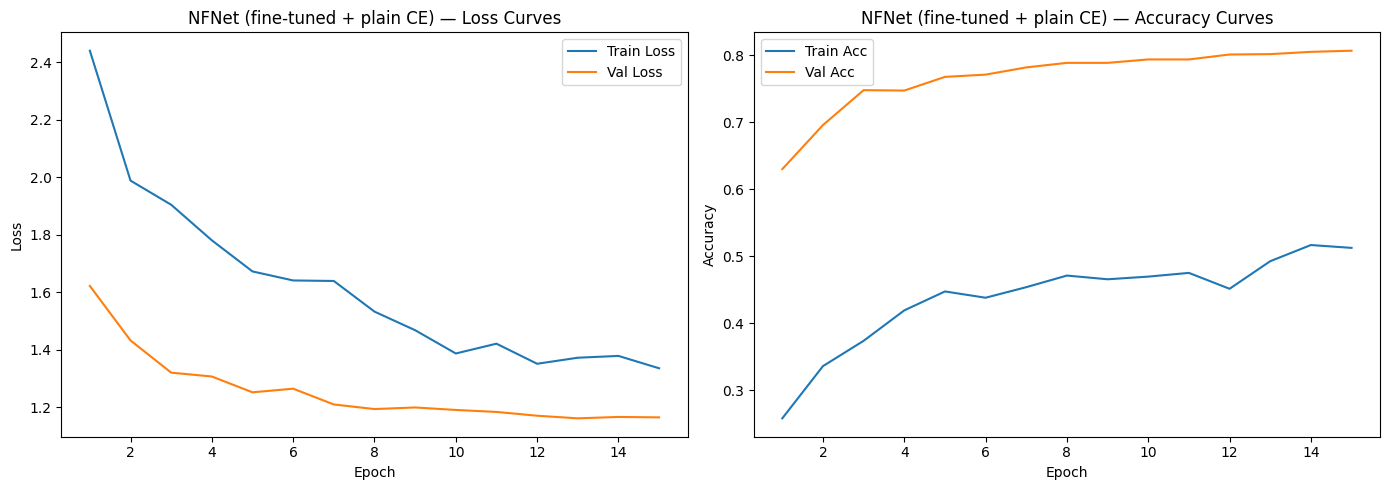

In [ ]:
class_names = train_loader.dataset.classes
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("NFNet (fine-tuned + plain CE) — Loss Curves")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("NFNet (fine-tuned + plain CE) — Accuracy Curves")
axes[1].legend()

plt.tight_layout()
plt.savefig("nfnet_training_curves.png", dpi=150)
plt.show()

## Confusion matrix

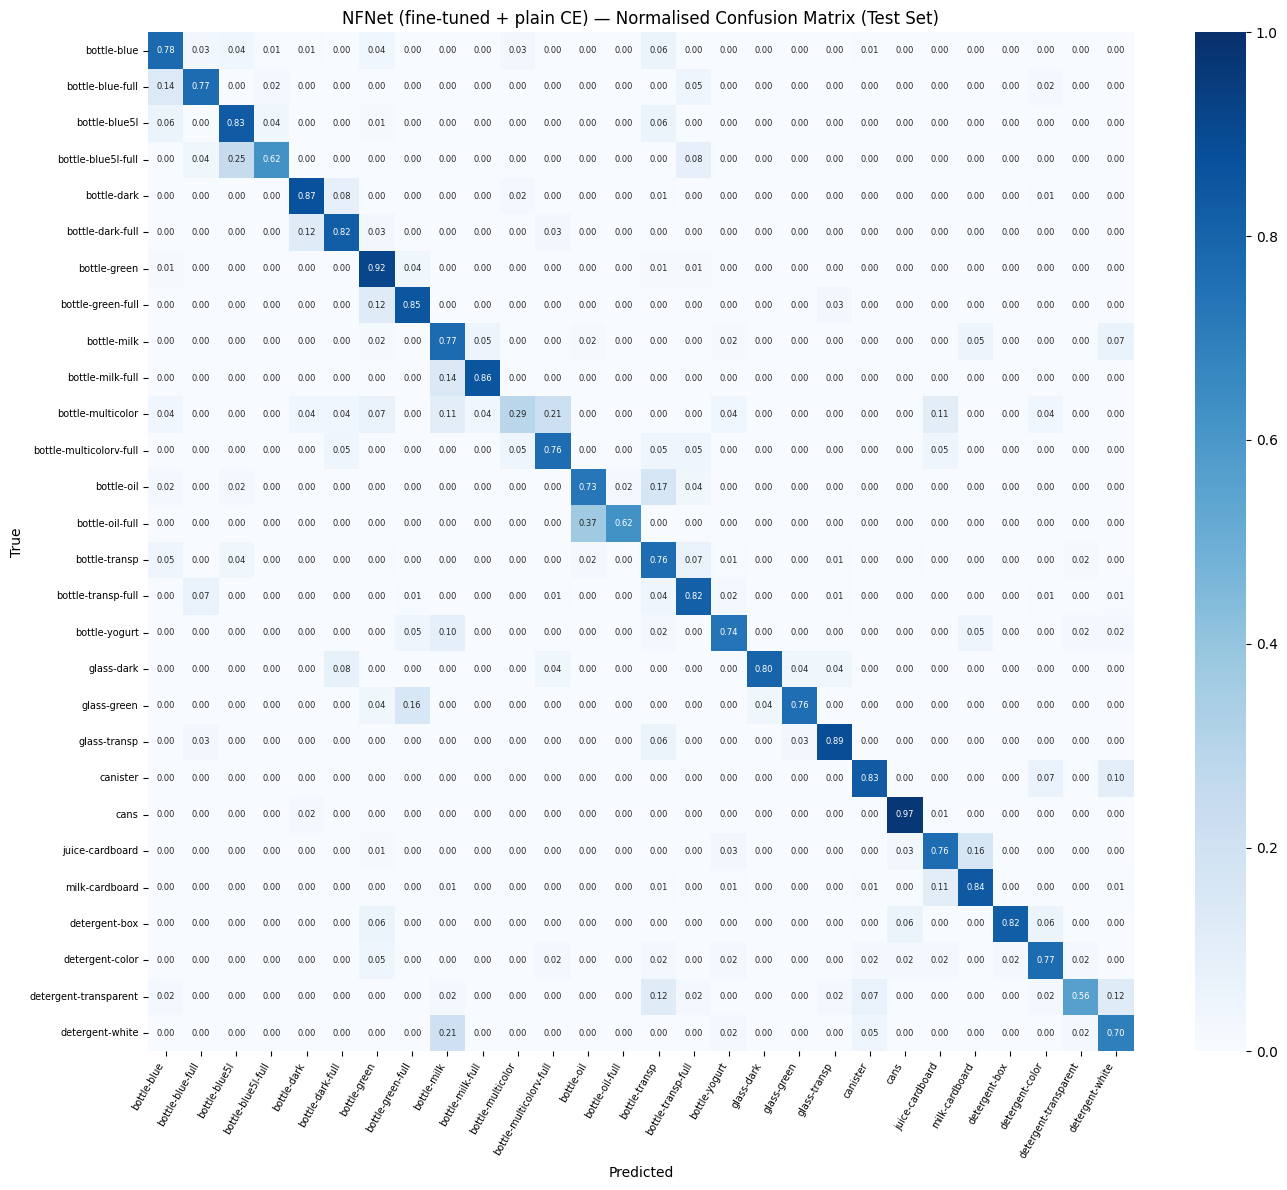

In [ ]:
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f",
    xticklabels=class_names, yticklabels=class_names,
    cmap="Blues", vmin=0, vmax=1, ax=ax, annot_kws={"size": 6}
)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("True", fontsize=10)
ax.set_title("NFNet (fine-tuned + plain CE) — Normalised Confusion Matrix (Test Set)", fontsize=12)
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("nfnet_confusion_matrix.png", dpi=150)
plt.show()

## Per-class F1

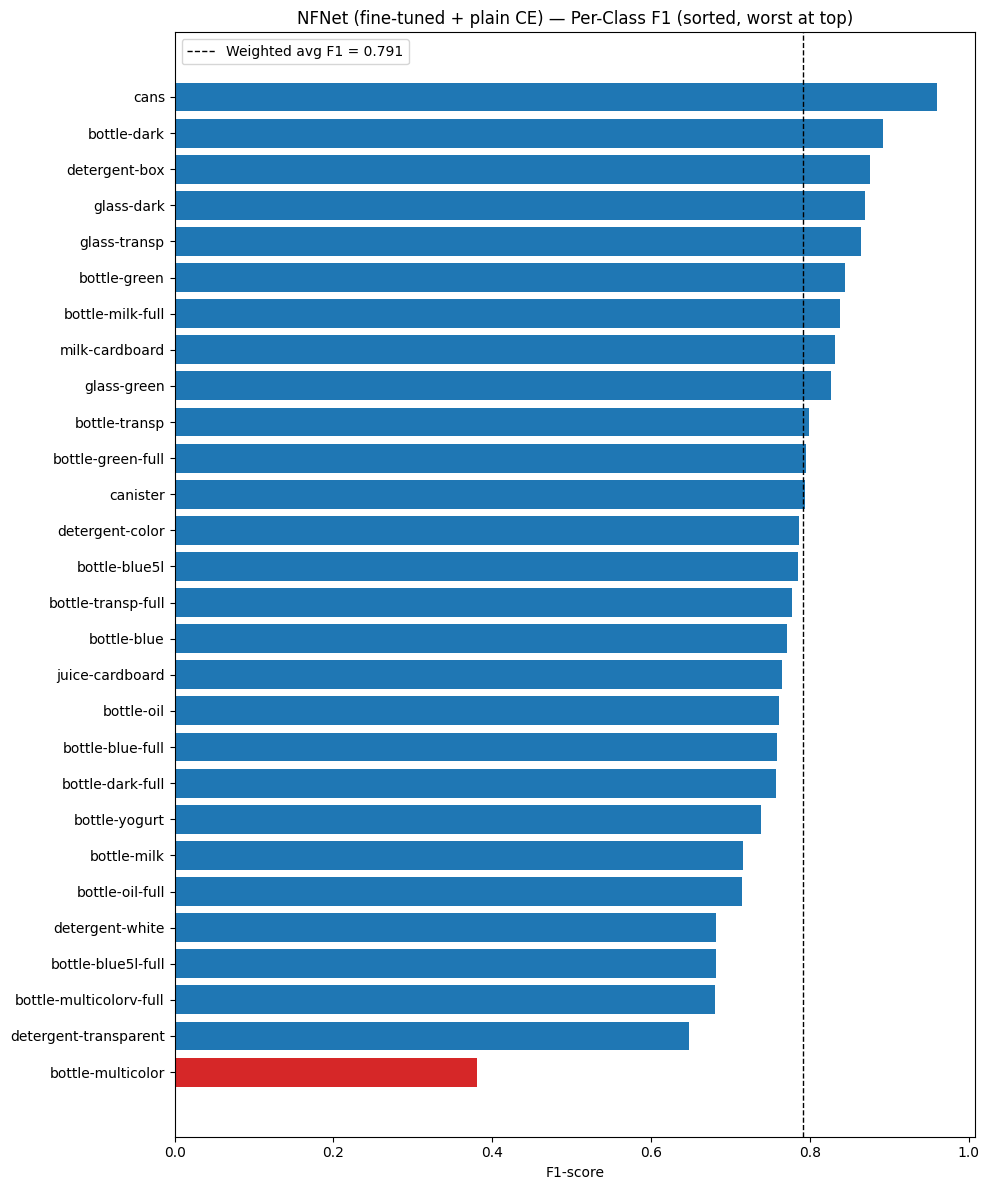

In [ ]:
_, _, per_class_f1, support = precision_recall_fscore_support(
    test_labels, test_preds, average=None, zero_division=0, labels=range(num_classes)
)

order = np.argsort(per_class_f1)
sorted_names = [class_names[i] for i in order]
sorted_f1 = per_class_f1[order]

fig, ax = plt.subplots(figsize=(10, 12))
colors = ["#d62728" if v < 0.5 else "#1f77b4" for v in sorted_f1]
ax.barh(sorted_names, sorted_f1, color=colors)
ax.set_xlabel("F1-score")
ax.set_title("NFNet (fine-tuned + plain CE) — Per-Class F1 (sorted, worst at top)")
ax.axvline(f1, color="black", linestyle="--", linewidth=1, label=f"Weighted avg F1 = {f1:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig("nfnet_per_class_f1.png", dpi=150)
plt.show()

## Most-confused class pairs

The actual failure-mode signal -- which specific classes get mixed up,
not just the aggregate accuracy number.

In [ ]:
def top_confused_pairs(cm, class_names, top_k=10):
    cm_copy = cm.copy().astype(float)
    np.fill_diagonal(cm_copy, 0)
    flat_idx = np.argsort(cm_copy.flatten())[::-1][:top_k]
    pairs = []
    for idx in flat_idx:
        i, j = np.unravel_index(idx, cm_copy.shape)
        if cm_copy[i, j] > 0:
            pairs.append((class_names[i], class_names[j], int(cm_copy[i, j])))
    return pairs

confused_pairs = top_confused_pairs(cm, class_names)
print("Top 10 most-confused (true -> predicted) class pairs:\n")
for true_cls, pred_cls, count in confused_pairs:
    print(f"  {true_cls:25s} -> {pred_cls:25s} : {count} times")

Top 10 most-confused (true -> predicted) class pairs:

  bottle-transp             -> bottle-transp-full        : 17 times
  juice-cardboard           -> milk-cardboard            : 11 times
  bottle-transp             -> bottle-blue               : 11 times
  milk-cardboard            -> juice-cardboard           : 10 times
  bottle-transp             -> bottle-blue5l             : 10 times
  detergent-white           -> bottle-milk               : 9 times
  bottle-oil                -> bottle-transp             : 8 times
  bottle-dark               -> bottle-dark-full          : 8 times
  bottle-transp-full        -> bottle-blue-full          : 6 times
  bottle-multicolor         -> bottle-multicolorv-full   : 6 times


## Grad-CAM on misclassified examples


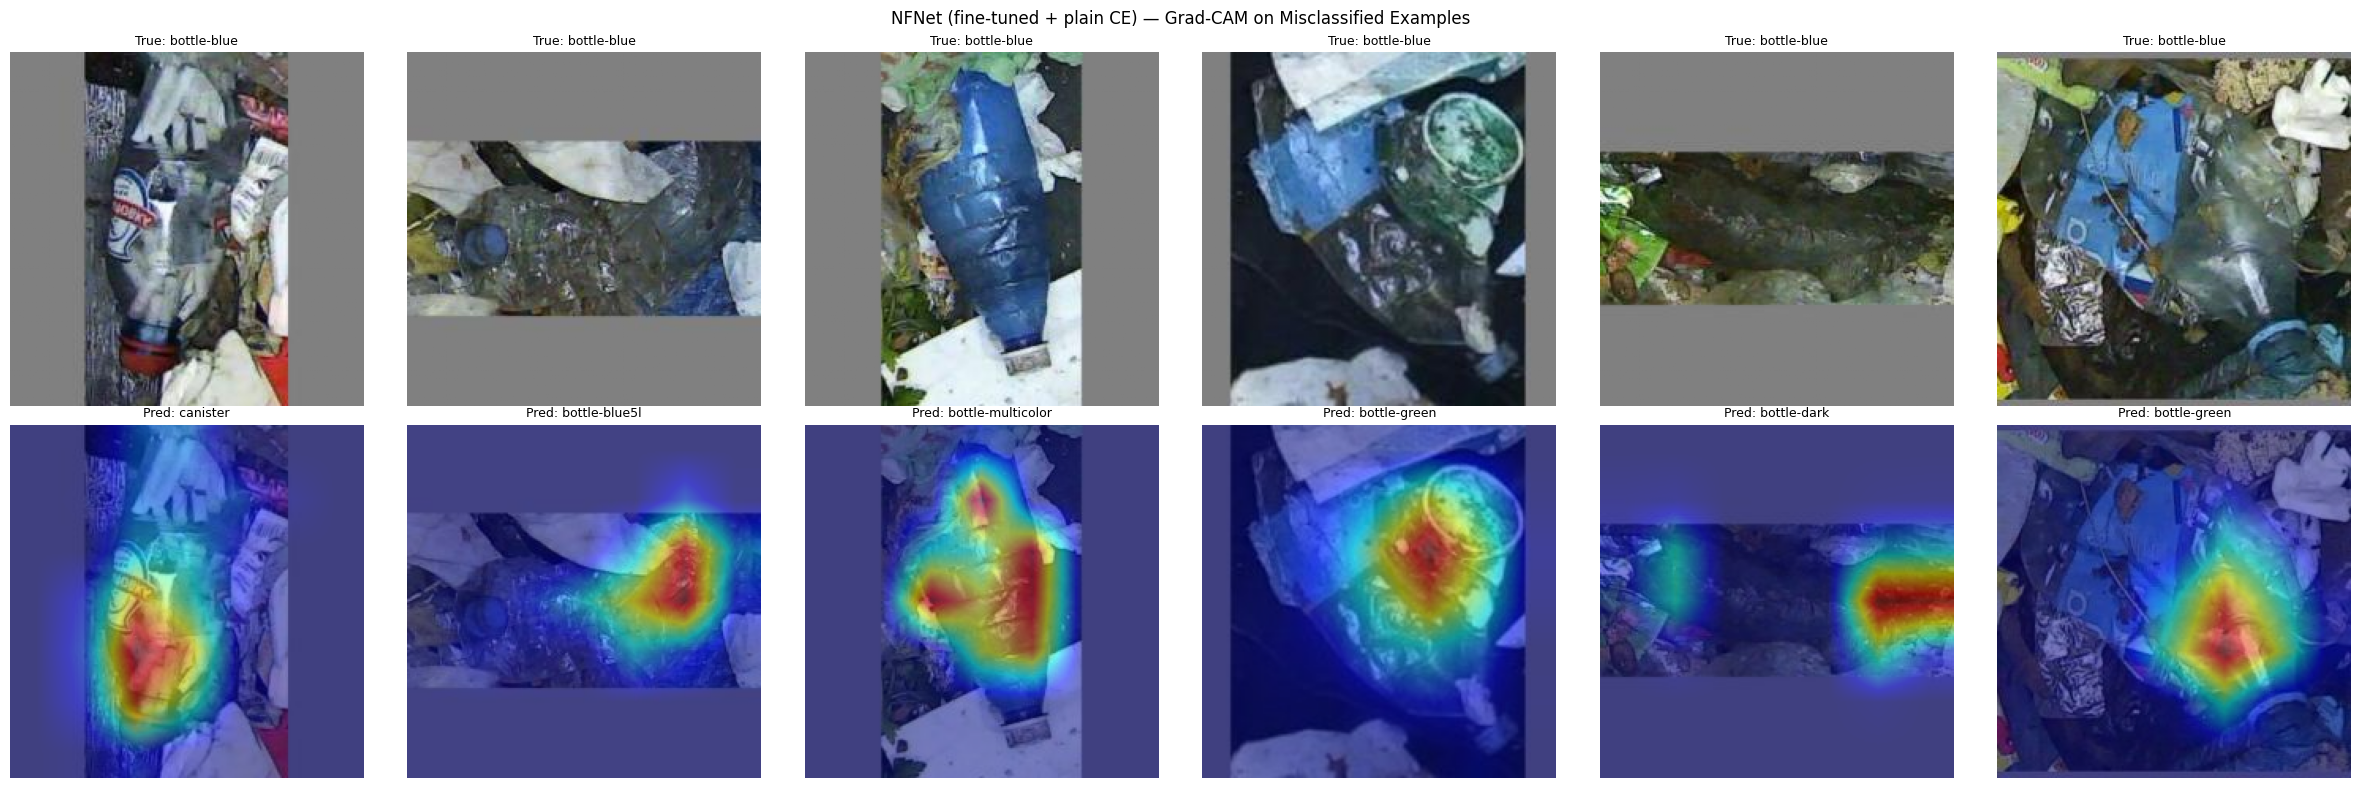

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from PIL import Image

target_layer = model.final_conv if hasattr(model, "final_conv") else list(model.children())[-3]
cam = GradCAM(model=model, target_layers=[target_layer])

misclassified_idx = [i for i, (p, l) in enumerate(zip(test_preds, test_labels)) if p != l][:6]

fig, axes = plt.subplots(2, len(misclassified_idx), figsize=(4 * len(misclassified_idx), 8))

for col, idx in enumerate(misclassified_idx):
    img_path, _ = test_ds.samples[idx]
    raw_img = Image.open(img_path).convert("RGB").resize((224, 224))
    img_np = np.array(raw_img) / 255.0

    input_tensor = eval_pipeline(raw_img).unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    cam_overlay = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f"True: {class_names[test_labels[idx]]}", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(cam_overlay)
    axes[1, col].set_title(f"Pred: {class_names[test_preds[idx]]}", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("NFNet (fine-tuned + plain CE) — Grad-CAM on Misclassified Examples", fontsize=12)
plt.tight_layout()
plt.savefig("nfnet_gradcam_misclassified.png", dpi=150)
plt.show()

In [ ]:
final_results = {
    "config": {"freeze_backbone": CFG["freeze_backbone"], "loss_type": CFG["loss_type"]},
    "test_acc": float(test_acc),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "history": history,
    "top_confused_pairs": confused_pairs,
    "per_class_f1": {class_names[i]: float(per_class_f1[i]) for i in range(num_classes)},
}

with open(f"{CONFIG_NAME}_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

np.savez(f"{CONFIG_NAME}_test_predictions.npz",
         preds=np.array(test_preds), labels=np.array(test_labels),
         class_names=np.array(train_loader.dataset.classes))

torch.save(model.state_dict(), f"{CONFIG_NAME}_final.pth")

from google.colab import files
files.download(f"{CONFIG_NAME}_results.json")
files.download(f"{CONFIG_NAME}_test_predictions.npz")
files.download(f"{CONFIG_NAME}_final.pth")
files.download("nfnet_training_curves.png")
files.download("nfnet_confusion_matrix.png")
files.download("nfnet_per_class_f1.png")
files.download("nfnet_gradcam_misclassified.png")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>